In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

import scipy
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from scipy.stats import norm

import multiprocessing as mp

import sys

parent_dir = ".."
sys.path.append(parent_dir)

import utilities as utils

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/Murphy_pharma").is_dir()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository or a subfolder containing data/Murphy_pharma above it.")
DATA_DIR = ROOT / "data/Murphy_pharma"
pd.set_option("display.max_columns", 24)
print(f"Data: {DATA_DIR}\nSciPy: {scipy.__version__}")

mean_neg, mean_pos = -28, 28
std = 28
P0 = np.array([[0.5], [0.5]])
Hlow = 0.1
Hhigh = 0.9

Data: /workspaces/Copy_Murphy2021/data/Murphy_pharma
SciPy: 1.11.4


In [2]:
from scipy.stats import norm

def P_source_g_samples(samples_arr,mean_neg,mean_pos,std,h,P0,window_size=None):
    P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
    # P_sample_g_neg = norm(loc=mean_neg, scale=std)
    # P_sample_g_pos = norm(loc=mean_pos, scale=std)
    Lneg = P_sample_g_neg[samples_arr + 90]
    Lpos = P_sample_g_pos[samples_arr + 90]
    L = np.concatenate((Lneg[:,np.newaxis,:],Lpos[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1, keepdims=True)
    return P.squeeze()

In [3]:
import multiprocessing as mp

import sys

parent_dir = ".."
sys.path.append(parent_dir)

import utilities as utils

def generate_trials(n_trials, n_draws, source_means, scale, H, mirror_trials=False, balanced_starts=False, seed=None):
    """Generate trials from a two-state switching Gaussian process.

    Parameters
    ----------
    n_trials : int
        Number of independent trials to generate.
    balanced_starts : bool, default=False
        If True, exactly half of the trials start in each source
        distribution. This requires an even ``n_trials``.
    seed : int or None, default=None
        Seed for NumPy's random-number generator. Use an integer for
        reproducible simulations.

    Returns
    -------
    X : ndarray of int, shape (n_trials, 12)
        Clipped and rounded observations for each trial.
    Y : ndarray of int, shape (n_trials,)
        Identity of the source for the final draw: 0 denotes the Gaussian
        with mean -17 and 1 denotes the Gaussian with mean 17.
    """
    if isinstance(n_trials, (bool, np.bool_)) or not isinstance(n_trials, (int, np.integer)):
        raise TypeError("n_trials must be an integer")
    if n_trials < 0:
        raise ValueError("n_trials must be non-negative")
    if (balanced_starts or mirror_trials) and n_trials % 2:
        raise ValueError("balanced_starts=True or mirror_trials=True requires an even n_trials")

    rng = np.random.default_rng(seed)
    n_draws = n_draws
    source_means = np.array(source_means)

    if mirror_trials:
        n_trials_ = n_trials // 2
    else:
        n_trials_ = n_trials

    if balanced_starts:
        starts = np.repeat([0, 1], n_trials_ // 2)
        rng.shuffle(starts)
    else:
        starts = rng.integers(0, 2, size=n_trials_)

    print(starts.shape)
    print(n_trials_)
    # switches[:, j] indicates whether the source changes between draws
    # j and j + 1. Cumulative parity therefore gives the source at each draw.
    switches = rng.random((n_trials_, n_draws - 1)) < H
    source_paths = np.column_stack(
        [starts, starts[:, None] ^ np.logical_xor.accumulate(switches, axis=1)]
    ).astype(int)

    raw_draws = rng.normal(loc=source_means[source_paths], scale=scale)
    X = np.rint(np.clip(raw_draws, -90, 90)).astype(int)
    Y = source_paths[:, -1].copy()
    if mirror_trials:
        X = np.concatenate([X, -X], axis=0)
        Y = np.concatenate([Y, 1-Y], axis=0)
    return X, Y

def IB_fn_emp(beta,p_RgX_emp,Yemp):
    Ixr = utils.compute_I_XR_emp(p_RgX_emp)
    Iry = utils.compute_I_RY_emp(p_RgX_emp,Yemp)
    return Ixr - beta*Iry

def mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_YgX_sample.shape[1]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX_sample) / np.sum(np.exp(betastar*p_YgX_sample),axis=1,keepdims=True)
        p_RX = p_RgX * (1/N_x)
        p_XgR = p_RX / p_R
        p_YgR = Yoh.T @ p_XgR
        IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)
        delta = 1
        iters = 0
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX_sample @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)


            # update p(r)
            p_R = p_RgX.sum(axis=0,keepdims=True) / N_x

            #update p(y|r)
            p_RX = p_RgX * (1/N_x)
            p_XgR = p_RX / p_R
            p_YgR = Yoh.T @ p_XgR

            IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = utils.compute_I_XR_emp(p_RgX)
    I_RY = utils.compute_I_RY_emp(p_RgX,Ysample)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_YgR, p_R, betastar]

def mc_IB_mp(args):
    return mc_IB(*args)

# mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True)
def get_mc_IB_bound(Ysample,p_YgX_sample,N_b=100,max_b=50,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=1, seed=209, sort_by_beta=True):

    if beta_array is None:
        beta_array = np.linspace(max_b/N_b,max_b,N_b)

    with mp.Pool(processes=N_threads) as pool:
        results = [pool.apply_async(mc_IB_mp, args=((beta_array[ib], Ysample, p_YgX_sample, iterlimit, init, N_inits, betastar_array[ib] if betastar_array is not None else None, seed, False),)) for ib in range(N_b)]
        results = [res.get() for res in results]
    I_XR = [res[0] for res in results]
    I_RY = [res[1] for res in results]
    betas = [res[2] for res in results]
    H_Rs = [res[3] for res in results]
    p_YgRs = [res[4] for res in results]
    p_Rs = [res[5] for res in results]

    if sort_by_beta:
        sort_indices = np.argsort(betas)
    else:
        sort_indices = np.arange(len(betas))
    out = {
        'I_XR': np.array(I_XR)[sort_indices],
        'I_RY': np.array(I_RY)[sort_indices],
        'beta': np.array(betas)[sort_indices],
        'H_R': np.array(H_Rs)[sort_indices],
        'p_YgR': np.array(p_YgRs)[sort_indices],
        'p_R': np.array(p_Rs)[sort_indices]
    }
    return out

In [4]:
n_draws = 10
source_means = [-28.0, 28.0]
mean_neg, mean_pos = source_means
std = 28.0
Hlow = 0.1
Hhigh = 0.9
Ntrials = 10000
Xlow, Ylow = generate_trials(Ntrials, n_draws, source_means, std, Hlow, mirror_trials=True, balanced_starts=True, seed=None)
Xhigh, Yhigh = generate_trials(Ntrials, n_draws, source_means, std, Hhigh, mirror_trials=True, balanced_starts=True, seed=None)

(5000,)
5000
(5000,)
5000


In [5]:
P_sample_g_neg = np.diff(np.concatenate([np.array([0]),norm(loc=mean_neg,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
P_sample_g_pos = np.diff(np.concatenate([np.array([0]),norm(loc=mean_pos,scale=std).cdf(np.arange(-89.5,90.5,1)),np.array([1])]))
P_sample = (P_sample_g_neg + P_sample_g_pos) / 2

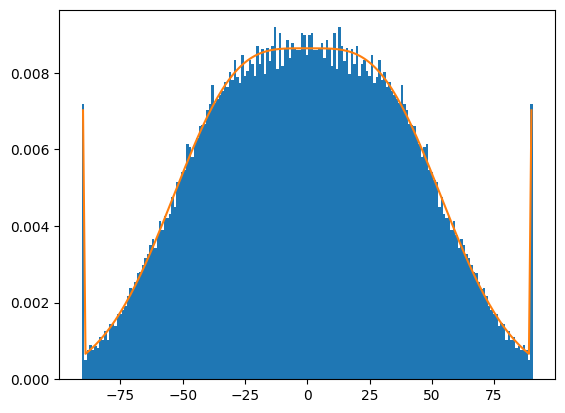

In [6]:
plt.hist(Xlow.flatten(), bins=np.arange(-90.5, 91.5, 1), density=True)
plt.plot(np.arange(-90, 91, 1), P_sample)

In [7]:
P0 = np.array([[0.5], [0.5]])
p_YgX_sample = P_source_g_samples(Xlow,mean_neg,mean_pos,std,Hlow,P0,window_size=None)
N_threads = 22
IB_bound_low = get_mc_IB_bound(Ylow,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

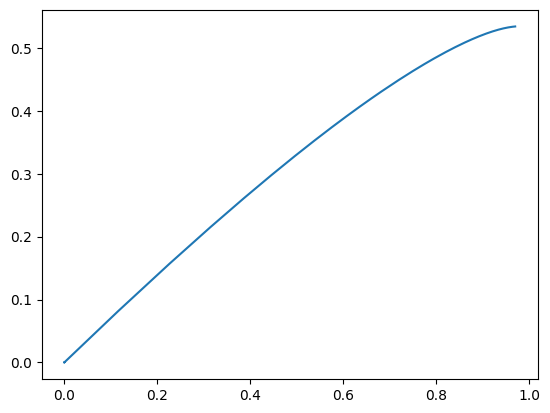

In [8]:
plt.plot(IB_bound_low['I_XR'],IB_bound_low['I_RY'])

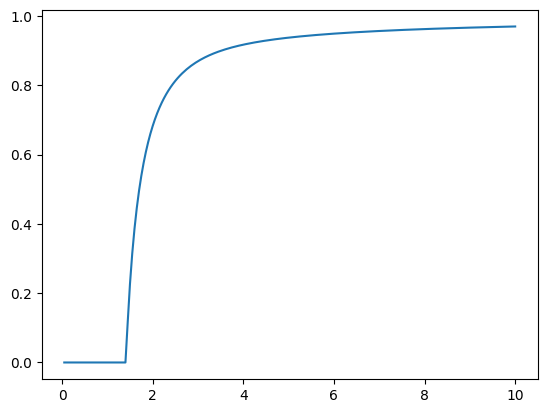

In [9]:
plt.plot(IB_bound_low['beta'], IB_bound_low['I_XR'])

In [10]:
p_YgX_sample = P_source_g_samples(Xhigh,mean_neg,mean_pos,std,Hhigh,P0,window_size=None)
IB_bound_high = get_mc_IB_bound(Yhigh,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

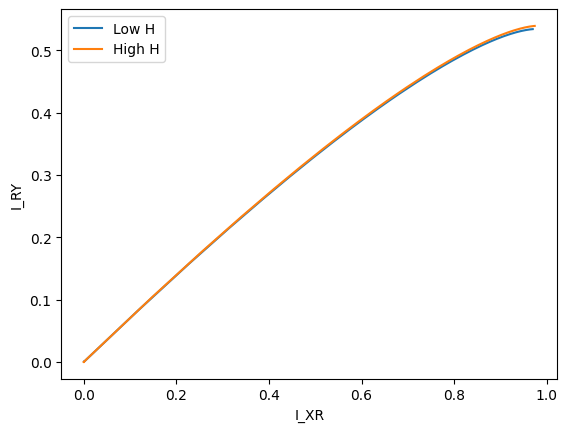

In [11]:
plt.plot(IB_bound_low['I_XR'],IB_bound_low['I_RY'])
plt.plot(IB_bound_high['I_XR'],IB_bound_high['I_RY'])
plt.xlabel('I_XR')
plt.ylabel('I_RY')
plt.legend(['Low H', 'High H'])
plt.show()

In [12]:
# 1 back bounds
p_YgX_sample = P_source_g_samples(Xlow,mean_neg,mean_pos,std,Hlow,P0,window_size=1)
IB_bound_low1b = get_mc_IB_bound(Ylow,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

p_YgX_sample = P_source_g_samples(Xhigh,mean_neg,mean_pos,std,Hhigh,P0,window_size=1)
IB_bound_high1b = get_mc_IB_bound(Yhigh,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

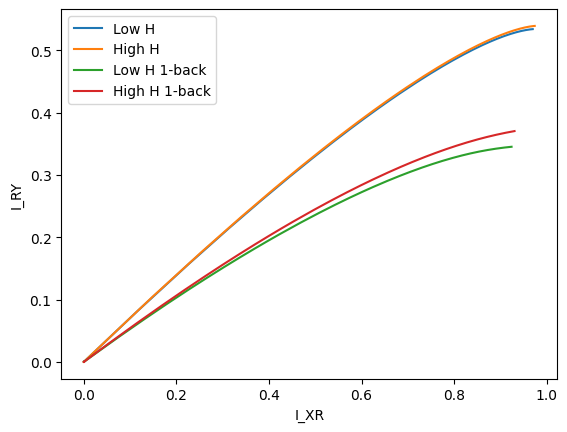

In [13]:
plt.plot(IB_bound_low['I_XR'],IB_bound_low['I_RY'])
plt.plot(IB_bound_high['I_XR'],IB_bound_high['I_RY'])
plt.plot(IB_bound_low1b['I_XR'],IB_bound_low1b['I_RY'])
plt.plot(IB_bound_high1b['I_XR'],IB_bound_high1b['I_RY'])
plt.xlabel('I_XR')
plt.ylabel('I_RY')
plt.legend(['Low H', 'High H', 'Low H 1-back', 'High H 1-back'])
plt.show()

In [14]:
# 3 back bounds
window_size = 3
p_YgX_sample = P_source_g_samples(Xlow,mean_neg,mean_pos,std,Hlow,P0,window_size=window_size)
IB_bound_low3b = get_mc_IB_bound(Ylow,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

p_YgX_sample = P_source_g_samples(Xhigh,mean_neg,mean_pos,std,Hhigh,P0,window_size=window_size)
IB_bound_high3b = get_mc_IB_bound(Yhigh,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

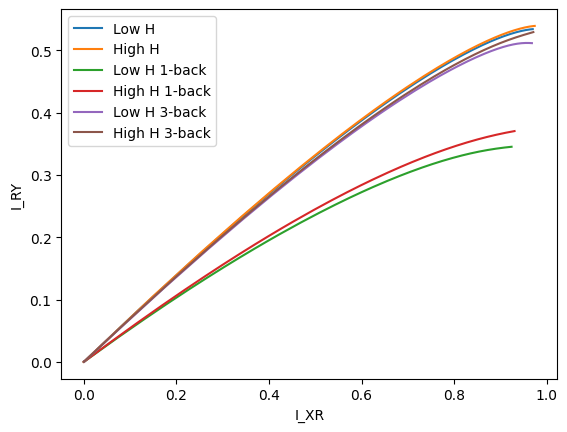

In [15]:
plt.plot(IB_bound_low['I_XR'],IB_bound_low['I_RY'])
plt.plot(IB_bound_high['I_XR'],IB_bound_high['I_RY'])
plt.plot(IB_bound_low1b['I_XR'],IB_bound_low1b['I_RY'])
plt.plot(IB_bound_high1b['I_XR'],IB_bound_high1b['I_RY'])
plt.plot(IB_bound_low3b['I_XR'],IB_bound_low3b['I_RY'])
plt.plot(IB_bound_high3b['I_XR'],IB_bound_high3b['I_RY'])
plt.xlabel('I_XR')
plt.ylabel('I_RY')
plt.legend(['Low H', 'High H', 'Low H 1-back', 'High H 1-back', 'Low H 3-back', 'High H 3-back'])
plt.show()

In [16]:
# 2 back bounds
window_size = 2
p_YgX_sample = P_source_g_samples(Xlow,mean_neg,mean_pos,std,Hlow,P0,window_size=window_size)
IB_bound_low2b = get_mc_IB_bound(Ylow,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

p_YgX_sample = P_source_g_samples(Xhigh,mean_neg,mean_pos,std,Hhigh,P0,window_size=window_size)
IB_bound_high2b = get_mc_IB_bound(Yhigh,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

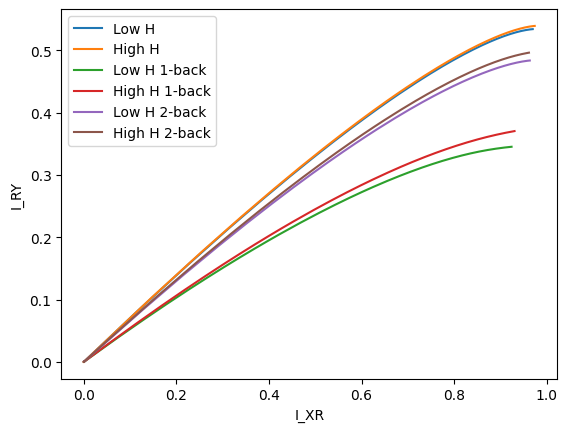

In [17]:
plt.plot(IB_bound_low['I_XR'],IB_bound_low['I_RY'])
plt.plot(IB_bound_high['I_XR'],IB_bound_high['I_RY'])
plt.plot(IB_bound_low1b['I_XR'],IB_bound_low1b['I_RY'])
plt.plot(IB_bound_high1b['I_XR'],IB_bound_high1b['I_RY'])
plt.plot(IB_bound_low2b['I_XR'],IB_bound_low2b['I_RY'])
plt.plot(IB_bound_high2b['I_XR'],IB_bound_high2b['I_RY'])
plt.xlabel('I_XR')
plt.ylabel('I_RY')
plt.legend(['Low H', 'High H', 'Low H 1-back', 'High H 1-back', 'Low H 2-back', 'High H 2-back'])
plt.show()

In [18]:
bounds = {
    '0.1': IB_bound_low,
    '0.9': IB_bound_high,
}



In [19]:
metadata_df = pd.read_csv('metadata.csv')
trials_df = pd.read_csv('trials.csv')
stimuli_df = pd.read_csv('stimuli.csv')

In [20]:
metadata_df

,participant,session,run,H,drug,n_blocks,n_trials,block_numbers,block_number_gap
0,CMC,1,1,0.9,atomoxetine,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
1,CMC,1,2,0.1,atomoxetine,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
2,CMC,2,1,0.1,placebo,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
3,CMC,2,2,0.9,placebo,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
4,CMC,3,1,0.9,donepizil,8,647,"(1, 2, 3, 4, 5, 6, 7, 8)",False
...,...,...,...,...,...,...,...,...,...
175,XUE,1,2,0.9,atomoxetine,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
176,XUE,2,1,0.1,donepizil,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
177,XUE,2,2,0.9,donepizil,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False
178,XUE,3,1,0.9,placebo,8,688,"(1, 2, 3, 4, 5, 6, 7, 8)",False


In [21]:
trials_df

,final_distribution,response,accuracy,rt_s,start_time_raw,fixation_break_count,trial_id,participant,session,run,block,trial_in_block,n_samples,n_samples_presented,source_behavior,presentation_complete,valid_response,analysis_valid,has_fixation_break,planned_final_distribution,H,drug
0,2.0,2.0,1.0,0.046685,1.517912e+09,0.0,CMC_S1_R1_B1_T1,CMC,1,1,1,1,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,2.0,0.9,atomoxetine
1,1.0,1.0,1.0,0.812104,1.517912e+09,0.0,CMC_S1_R1_B1_T2,CMC,1,1,1,2,5,5,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
2,1.0,1.0,1.0,0.954936,1.517912e+09,0.0,CMC_S1_R1_B1_T3,CMC,1,1,1,3,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
3,1.0,2.0,0.0,0.470086,1.517912e+09,0.0,CMC_S1_R1_B1_T4,CMC,1,1,1,4,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
4,1.0,1.0,1.0,0.623945,1.517912e+09,0.0,CMC_S1_R1_B1_T5,CMC,1,1,1,5,10,10,CMC/CMC/S1/R1/Behaviour/CMC_1_1.mat,True,True,True,False,1.0,0.9,atomoxetine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120887,2.0,2.0,1.0,0.311655,1.512147e+09,0.0,XUE_S3_R2_B8_T82,XUE,3,2,8,82,10,10,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,2.0,0.1,placebo
120888,1.0,1.0,1.0,0.031287,1.512147e+09,0.0,XUE_S3_R2_B8_T83,XUE,3,2,8,83,10,10,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,1.0,0.1,placebo
120889,1.0,1.0,1.0,0.096594,1.512147e+09,0.0,XUE_S3_R2_B8_T84,XUE,3,2,8,84,9,9,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,1.0,0.1,placebo
120890,2.0,2.0,1.0,0.062127,1.512147e+09,0.0,XUE_S3_R2_B8_T85,XUE,3,2,8,85,4,4,XUE/XUE/S3/R2/Behaviour/XUE_3_8.mat,True,True,True,False,2.0,0.1,placebo


In [22]:
stimuli_df

,trial_id,sample_in_trial,stimulus_value,generating_distribution,switch,onset_s,presented,participant,session,run,block,trial_in_block,drug,H,analysis_valid
0,CMC_S1_R1_B1_T1,1,1.0,1.0,0.0,0.400007,True,CMC,1,1,1,1,atomoxetine,0.9,True
1,CMC_S1_R1_B1_T1,2,-45.0,2.0,1.0,0.799996,True,CMC,1,1,1,1,atomoxetine,0.9,True
2,CMC_S1_R1_B1_T1,3,50.0,1.0,1.0,1.199986,True,CMC,1,1,1,1,atomoxetine,0.9,True
3,CMC_S1_R1_B1_T1,4,-84.0,2.0,1.0,1.599990,True,CMC,1,1,1,1,atomoxetine,0.9,True
4,CMC_S1_R1_B1_T1,5,21.0,1.0,1.0,1.999984,True,CMC,1,1,1,1,atomoxetine,0.9,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019142,XUE_S3_R2_B8_T86,6,20.0,1.0,0.0,2.399967,True,XUE,3,2,8,86,placebo,0.1,True
1019143,XUE_S3_R2_B8_T86,7,12.0,1.0,0.0,2.799972,True,XUE,3,2,8,86,placebo,0.1,True
1019144,XUE_S3_R2_B8_T86,8,5.0,1.0,0.0,3.199954,True,XUE,3,2,8,86,placebo,0.1,True
1019145,XUE_S3_R2_B8_T86,9,69.0,1.0,0.0,3.599953,True,XUE,3,2,8,86,placebo,0.1,True


In [23]:
import utilities as utils

from choice_information import (
    default_model_library,
    estimate_choice_information,
    bootstrap_choice_information,
    plot_choice_information_diagnostics,
    plot_bootstrap_choice_information,
)

ibdf = pd.DataFrame({
    'subject_ID': [],
    'subject_index': [],
    'session': [],
    'run': [],
    'H': [],
    'drug': [],
    'Ntrials': [],
    'Ixr': [],
    'Iry': [],
    'Iry_CI_lower': [],
    'Iry_CI_upper': []
})

Rcard = 2
Ycard = 2

CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations
N_threads = 15 # number of threads for parallel processing

participants = metadata_df['participant'].unique()
drugs = metadata_df['drug'].unique()
H_values = metadata_df['H'].unique()

# participants = ['CMC']

for ii, participant in enumerate(participants):
    sjtrials_df = trials_df.loc[trials_df['participant'] == participant]
    sjstimuli_df = stimuli_df.loc[stimuli_df['participant'] == participant]
    conds = (sjtrials_df['n_samples_presented']==10) & (sjtrials_df['valid_response']) & (sjtrials_df['presentation_complete'])
    for drug in drugs:
        conds2 = conds & (sjtrials_df['drug'] == drug)
        for H in H_values:
            conds3 = conds2 & (sjtrials_df['H'] == H)
            trials = sjtrials_df.loc[conds3,'trial_id']
            X = np.array([sjstimuli_df.loc[sjstimuli_df['trial_id']==trial_id,'stimulus_value'].values for trial_id in trials])
            R = np.array([sjtrials_df.loc[sjtrials_df['trial_id']==trial_id,'response'].values for trial_id in trials], dtype=int).squeeze()
            Y = np.array([sjtrials_df.loc[sjtrials_df['trial_id']==trial_id,'final_distribution'].values for trial_id in trials], dtype=int).squeeze()

            R = R - 1
            Y = Y - 1

            result = estimate_choice_information(
                    X,
                    R,
                    fold_mode="random",
                    n_splits=5,
                    inner_n_splits=3,
                    random_state=2026,
                )

            Ixr = result["mi_lower_bound_bits"]
            Iry = utils.mutual_inf_nsb(R, Y, [Rcard, Ycard])

            Iry_CI = utils.get_Iry_CI(R,Y,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)

            sjdf = pd.DataFrame({
                'subject_ID': [''],
                'subject_index': [np.nan],
                'session': [np.nan],
                'run': [np.nan],
                'drug': [''],
                'Ntrials': [np.nan],
                'H': [np.nan],
                'Ixr': [np.nan],
                'Iry': [np.nan],
                'Iry_CI_lower': [np.nan],
                'Iry_CI_upper': [np.nan]
            })

            conds4 = (metadata_df['participant'] == participant) & (metadata_df['drug'] == drug) & (metadata_df['H'] == H)

            sjdf['subject_ID'] = participant
            sjdf['subject_index'] = ii
            sjdf['session'] = metadata_df.loc[conds4, 'session'].values[0]
            sjdf['run'] = metadata_df.loc[conds4, 'run'].values[0]
            sjdf['drug'] = drug
            sjdf['Ntrials'] = len(trials)
            sjdf['H'] = H
            sjdf['Ixr'] = Ixr
            sjdf['Iry'] = Iry
            sjdf['Iry_CI_lower'] = Iry_CI[0]
            sjdf['Iry_CI_upper'] = Iry_CI[1]

            ibdf = pd.concat([ibdf, sjdf], ignore_index=True)

In [24]:
ibdf.to_csv('ibdf.csv', index=False)

In [25]:
ibdf = pd.read_csv('ibdf.csv')

In [26]:
ibdf

,subject_ID,subject_index,session,run,H,drug,Ntrials,Ixr,Iry,Iry_CI_lower,Iry_CI_upper
0,CMC,0.0,1.0,1.0,0.9,atomoxetine,448.0,0.494586,0.325351,0.252697,0.407877
1,CMC,0.0,1.0,2.0,0.1,atomoxetine,447.0,0.449716,0.291766,0.220310,0.365524
2,CMC,0.0,2.0,2.0,0.9,placebo,448.0,0.587011,0.312079,0.241317,0.396254
3,CMC,0.0,2.0,1.0,0.1,placebo,448.0,0.529696,0.312238,0.241537,0.408838
4,CMC,0.0,3.0,1.0,0.9,donepizil,419.0,0.345680,0.281320,0.208357,0.363210
...,...,...,...,...,...,...,...,...,...,...,...
175,XUE,29.0,1.0,1.0,0.1,atomoxetine,448.0,0.769634,0.475547,0.393862,0.566326
176,XUE,29.0,3.0,1.0,0.9,placebo,448.0,0.928532,0.365547,0.291228,0.455457
177,XUE,29.0,3.0,2.0,0.1,placebo,448.0,0.786294,0.425226,0.340754,0.510967
178,XUE,29.0,2.0,2.0,0.9,donepizil,448.0,0.855971,0.281407,0.214199,0.358625


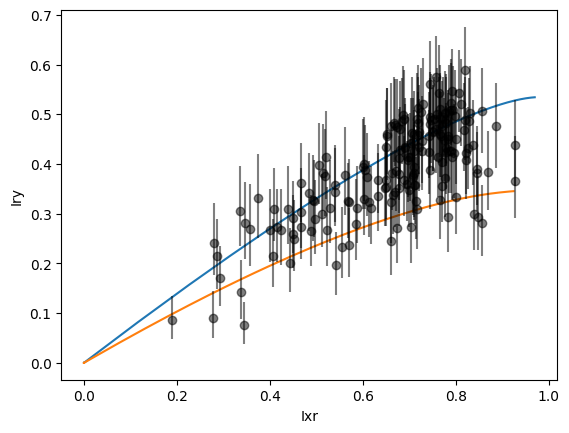

In [27]:
plt.plot(IB_bound_low['I_XR'], IB_bound_low['I_RY'])
plt.plot(IB_bound_low1b['I_XR'], IB_bound_low1b['I_RY'])
plt.errorbar(ibdf['Ixr'], ibdf['Iry'], yerr=np.array([ibdf['Iry'].to_numpy() - ibdf['Iry_CI_lower'].to_numpy(), ibdf['Iry_CI_upper'].to_numpy() - ibdf['Iry'].to_numpy()]), fmt='o', c='k', alpha=0.5)
plt.xlabel('Ixr')
plt.ylabel('Iry')
plt.show()

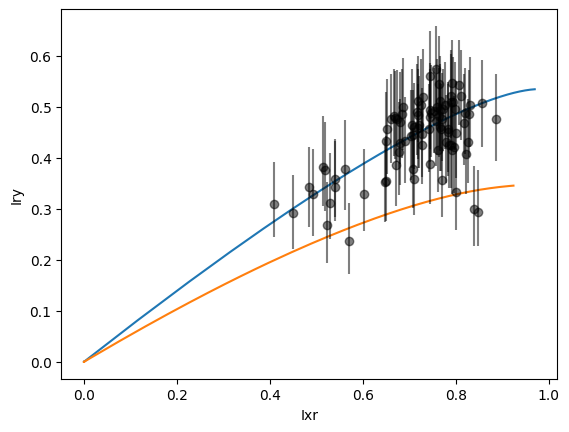

In [28]:
condslow = (ibdf['H'] == 0.1)
ibdf_low = ibdf[condslow]

plt.plot(IB_bound_low['I_XR'], IB_bound_low['I_RY'])
plt.plot(IB_bound_low1b['I_XR'], IB_bound_low1b['I_RY'])
plt.errorbar(ibdf_low['Ixr'], ibdf_low['Iry'], yerr=np.array([ibdf_low['Iry'].to_numpy() - ibdf_low['Iry_CI_lower'].to_numpy(), ibdf_low['Iry_CI_upper'].to_numpy() - ibdf_low['Iry'].to_numpy()]), fmt='o', c='k', alpha=0.5)
plt.xlabel('Ixr')
plt.ylabel('Iry')
plt.show()

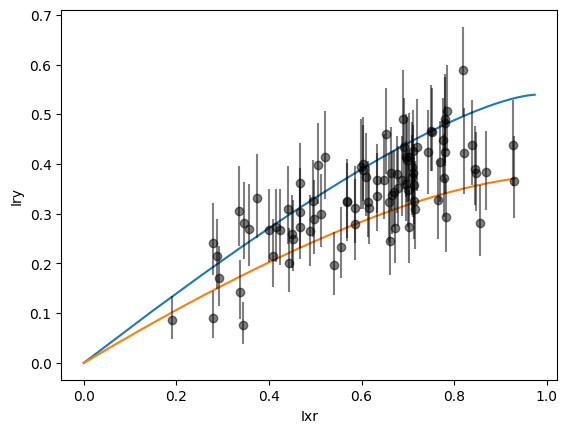

In [29]:
condshigh = (ibdf['H'] == 0.9)
ibdf_high = ibdf[condshigh]

plt.plot(IB_bound_high['I_XR'], IB_bound_high['I_RY'])
plt.plot(IB_bound_high1b['I_XR'], IB_bound_high1b['I_RY'])
plt.errorbar(ibdf_high['Ixr'], ibdf_high['Iry'], yerr=np.array([ibdf_high['Iry'].to_numpy() - ibdf_high['Iry_CI_lower'].to_numpy(), ibdf_high['Iry_CI_upper'].to_numpy() - ibdf_high['Iry'].to_numpy()]), fmt='o', c='k', alpha=0.5)
plt.xlabel('Ixr')
plt.ylabel('Iry')
plt.show()

## Within-participant condition comparisons

Compare **H = 0.1 → 0.9 within each drug**, and **placebo → each active drug within each H**. Each thin line connects the same participant in both conditions. Colored points identify conditions; large diamonds and a thick black line show the means of the paired participants. Panels report the number of complete pairs and mean change (second condition minus first, in bits).

The joint plots use `Ixr` on the x-axis and `Iry` on the y-axis. Only participants with finite values for both measures in both conditions enter a comparison, so all plots of a comparison use the same participants. The spelling `donepizil` follows the data. These are descriptive plots; the means are equally weighted across participants, and no significance tests or confidence intervals are implied.

Dashed curves in the joint plots show the IB bounds from `bounds`: both H bounds in H comparisons, and the corresponding fixed-H bound in drug comparisons. Rerun the comparison setup cell before the joint plotting cell after updating this section.

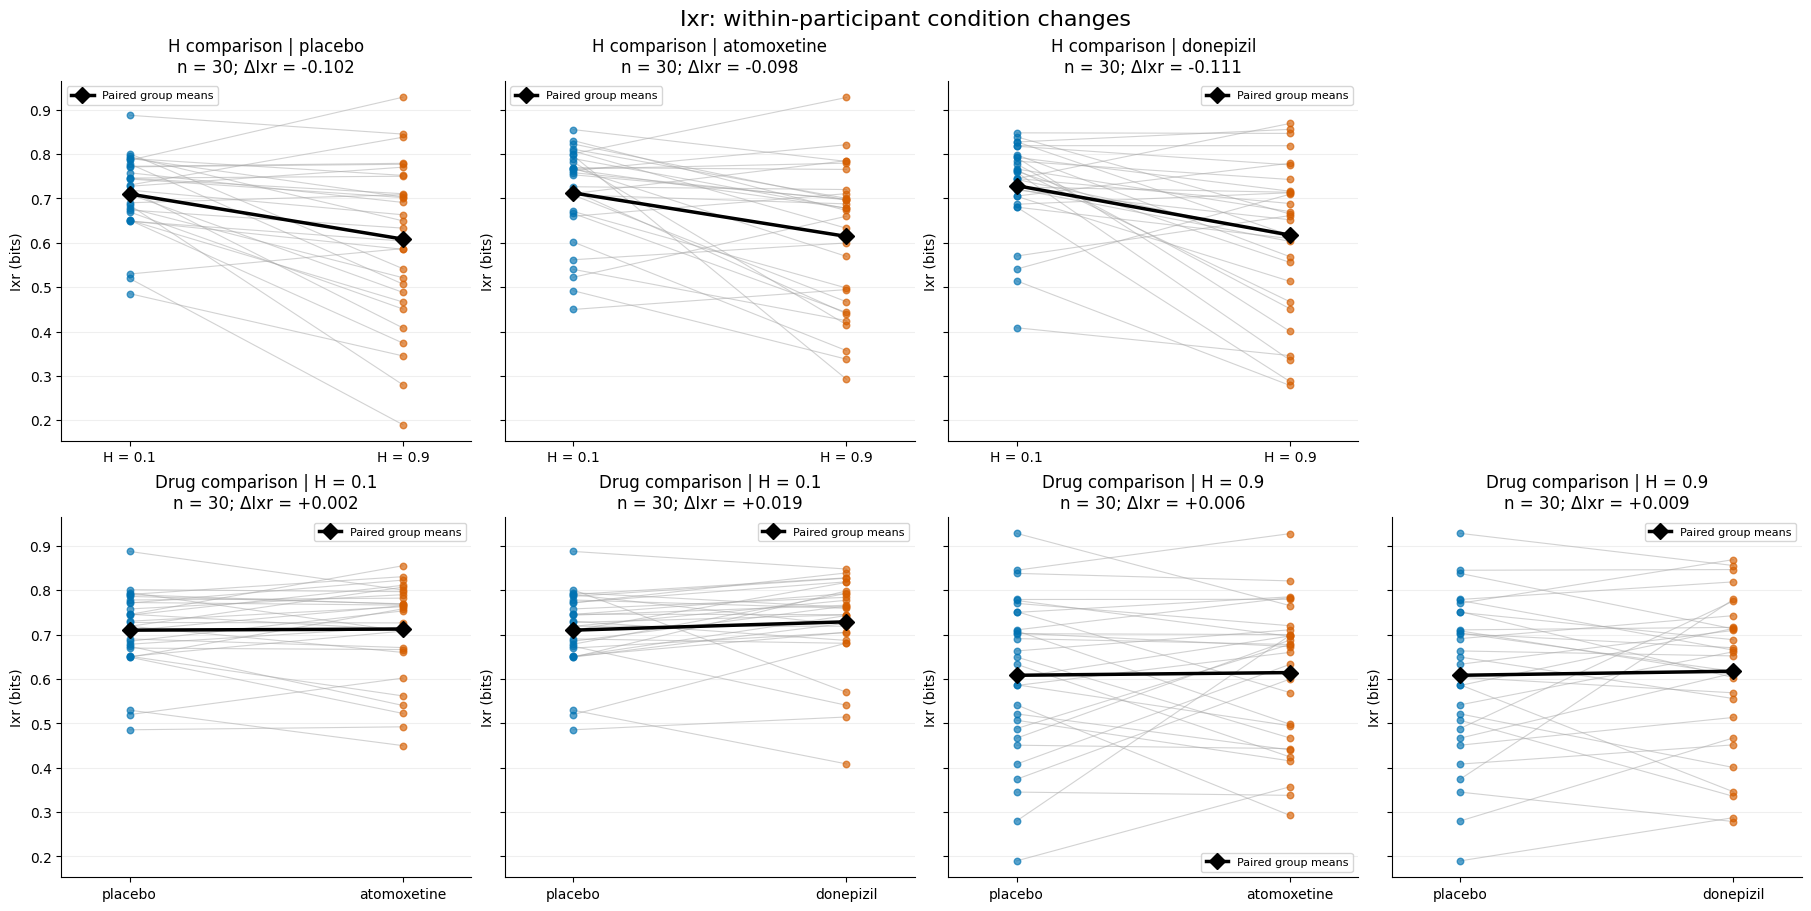

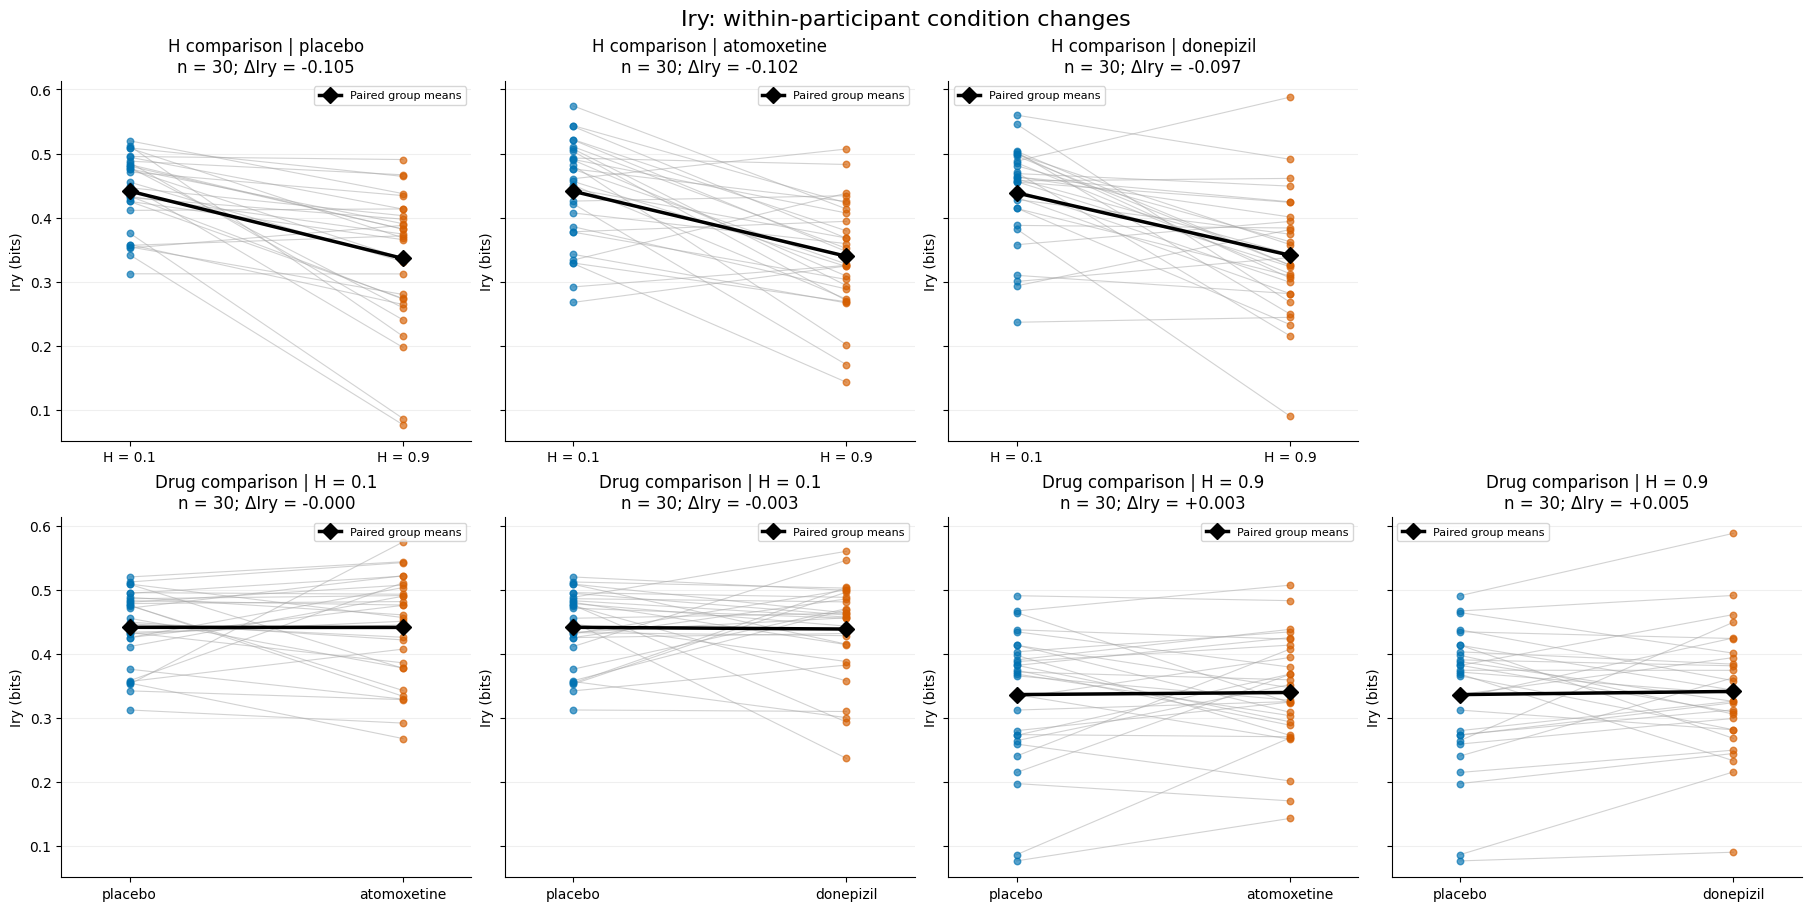

In [30]:
# Use the existing ibdf; these cells can also run after loading ibdf.csv.
plot_df = ibdf[['subject_ID', 'drug', 'H', 'Ixr', 'Iry']].copy()
plot_df['drug'] = plot_df['drug'].astype(str).str.strip().str.lower().replace(
    {'donepezil': 'donepizil'}
)
for column in ['H', 'Ixr', 'Iry']:
    plot_df[column] = pd.to_numeric(plot_df[column], errors='coerce')
plot_df[['Ixr', 'Iry']] = plot_df[['Ixr', 'Iry']].replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.loc[plot_df['H'].isin([0.1, 0.9]) &
                        plot_df['drug'].isin(['placebo', 'atomoxetine', 'donepizil'])]
if plot_df.duplicated(['subject_ID', 'drug', 'H']).any():
    raise ValueError('Expected one ibdf row per subject_ID, drug, and H.')

# Pair by participant, never by row position; retain complete joint pairs.
def ib_pairs(first, second):
    first = first.set_index('subject_ID')[['Ixr', 'Iry']]
    second = second.set_index('subject_ID')[['Ixr', 'Iry']]
    return first.join(second, how='inner', lsuffix='_1', rsuffix='_2').dropna()

ib_comparisons = []
for drug in ['placebo', 'atomoxetine', 'donepizil']:
    subset = plot_df.loc[plot_df['drug'] == drug]
    ib_comparisons.append({
        'title': f'H comparison | {drug}', 'labels': ('H = 0.1', 'H = 0.9'), 'H_values': (0.1, 0.9),
        'pairs': ib_pairs(subset.loc[subset['H'] == 0.1], subset.loc[subset['H'] == 0.9])
    })
for h in [0.1, 0.9]:
    subset = plot_df.loc[plot_df['H'] == h]
    for drug in ['atomoxetine', 'donepizil']:
        ib_comparisons.append({
            'title': f'Drug comparison | H = {h}', 'labels': ('placebo', drug), 'H_values': (h,),
            'pairs': ib_pairs(subset.loc[subset['drug'] == 'placebo'], subset.loc[subset['drug'] == drug])
        })

condition_colors = ('#0072B2', '#D55E00')

def ib_panel_title(comparison, measures):
    pairs = comparison['pairs']
    changes = ', '.join(
        f"Δ{measure} = {(pairs[measure + '_2'] - pairs[measure + '_1']).mean():+.3f}"
        for measure in measures
    ) if len(pairs) else 'No complete pairs'
    return f"{comparison['title']}\nn = {len(pairs)}; {changes}"

def ib_figure(title):
    fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=False, sharey=True,
                             constrained_layout=True)
    axes[0, 3].set_visible(False)
    panels = [*axes[0, :3], *axes[1, :]]
    fig.suptitle(title, fontsize=16)
    return fig, panels

# Separate figures for Ixr and Iry; each panel contains individual paired values.
ib_measure_figures = {}
for measure in ['Ixr', 'Iry']:
    fig, axes = ib_figure(f'{measure}: within-participant condition changes')
    for ax, comparison in zip(axes, ib_comparisons):
        pairs = comparison['pairs']
        values = pairs[[measure + '_1', measure + '_2']].to_numpy()
        if len(values):
            ax.plot([0, 1], values.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
            for j, (label, color) in enumerate(zip(comparison['labels'], condition_colors)):
                ax.scatter(np.full(len(values), j), values[:, j], color=color,
                           s=22, alpha=0.65, zorder=2)
            ax.plot([0, 1], values.mean(axis=0), '-D', color='black', lw=2.5,
                    markersize=8, label='Paired group means', zorder=3)
            ax.legend(fontsize=8)
        ax.set(xticks=[0, 1], xticklabels=comparison['labels'], xlim=(-0.25, 1.25),
               ylabel=f'{measure} (bits)', title=ib_panel_title(comparison, [measure]))
        ax.grid(axis='y', alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)
    ib_measure_figures[measure] = fig
    plt.show()


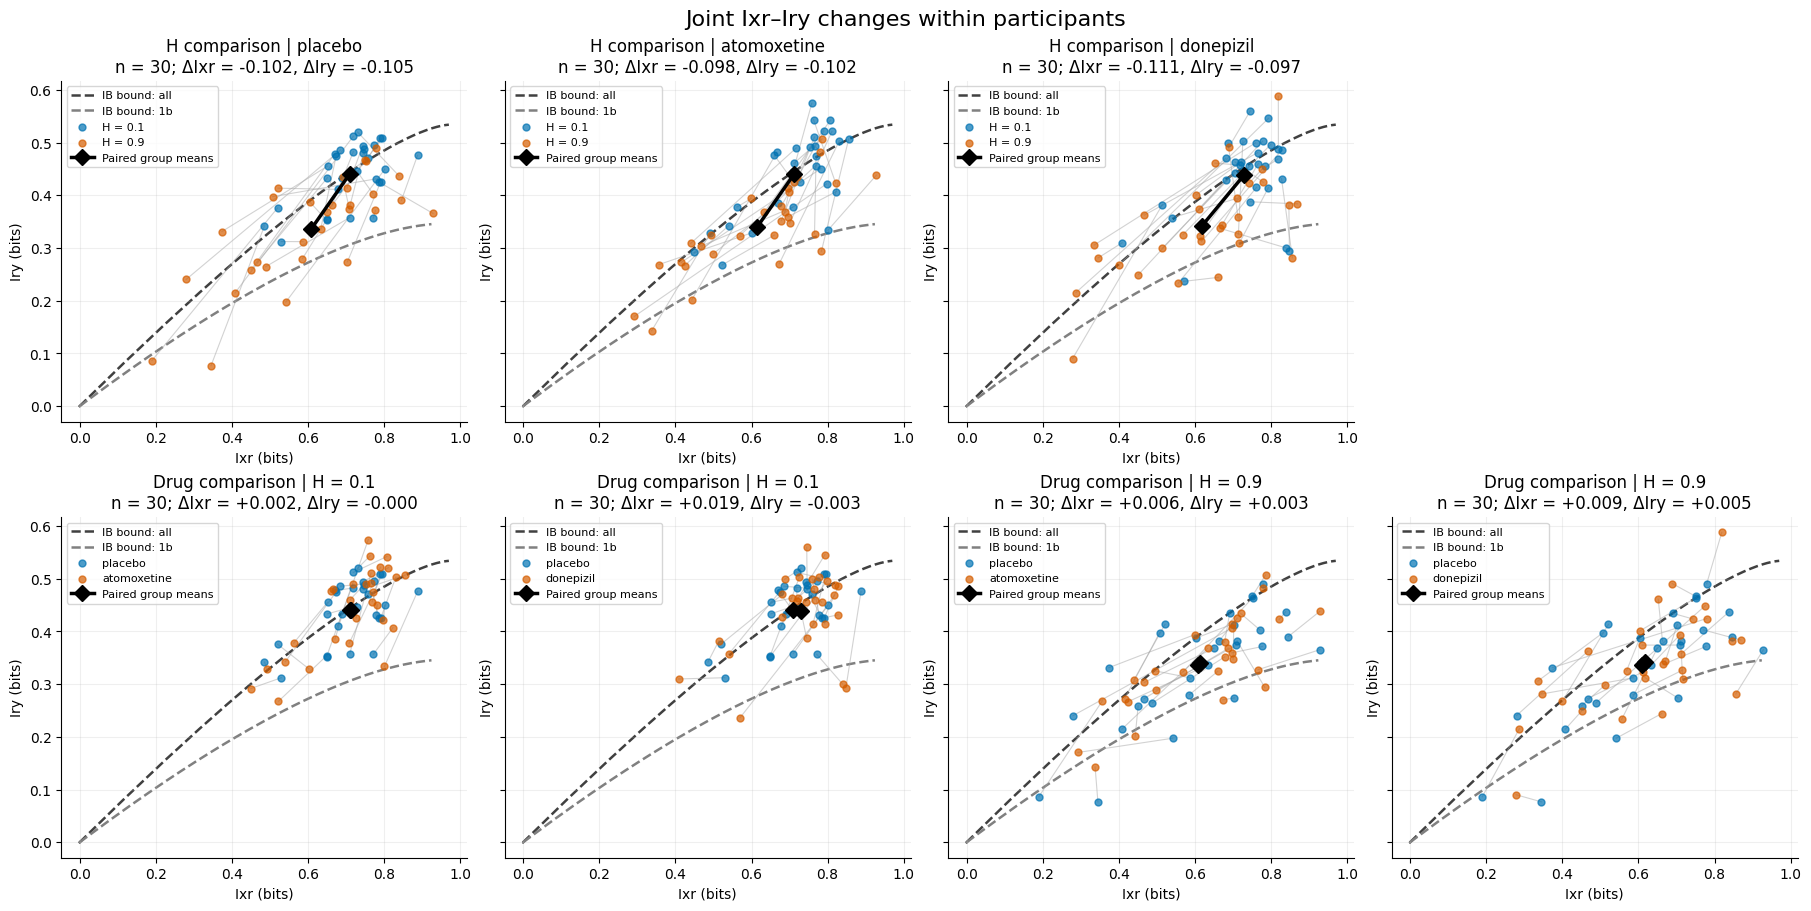

In [32]:
# Joint Ixr–Iry plots: each segment connects a participant's two conditions.
ib_joint_figure, axes = ib_figure('Joint Ixr–Iry changes within participants')
# Use common limits across all panels so displacement is visually comparable.
for ax in axes[1:]:
    ax.sharex(axes[0])
for ax, comparison in zip(axes, ib_comparisons):
    # H comparisons show both bounds; drug comparisons show the fixed-H bound.
    ax.plot(IB_bound_low['I_XR'], IB_bound_low['I_RY'], '--', color='0.25', lw=1.8,
            label='IB bound: all', zorder=0)
    ax.plot(IB_bound_low1b['I_XR'], IB_bound_low1b['I_RY'], '--', color='0.5', lw=1.8,
            label='IB bound: 1b', zorder=0)
    # for h in comparison['H_values']:
    #     bound = bounds[str(h)]
    #     color = condition_colors[0 if h == 0.1 else 1] if len(comparison['H_values']) == 2 else '0.25'
    #     ax.plot(bound['I_XR'], bound['I_RY'], '--', color=color, lw=1.8,
    #             label=f'IB bound: H = {h}', zorder=0)
    pairs = comparison['pairs']
    if len(pairs):
        xs = pairs[['Ixr_1', 'Ixr_2']].to_numpy()
        ys = pairs[['Iry_1', 'Iry_2']].to_numpy()
        ax.plot(xs.T, ys.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
        for j, (label, color) in enumerate(zip(comparison['labels'], condition_colors)):
            ax.scatter(xs[:, j], ys[:, j], color=color, s=25, alpha=0.7,
                       label=label, zorder=2)
        ax.plot(xs.mean(axis=0), ys.mean(axis=0), '-D', color='black', lw=2.5,
                markersize=8, label='Paired group means', zorder=3)
    ax.legend(fontsize=8)
    ax.set(xlabel='Ixr (bits)', ylabel='Iry (bits)',
           title=ib_panel_title(comparison, ['Ixr', 'Iry']))
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Within-participant session and run comparisons

Compare sessions **1 → 2**, **1 → 3**, and **2 → 3**, and runs **1 → 2**. For each measure, first take the arithmetic mean of the existing condition estimates within each participant and session (across its two runs), or within each participant and run (across its three sessions). These are means of the estimated information measures, not information estimates recomputed from pooled trials. Each participant has equal weight in the group means.

Thin lines connect individual participants; colored points identify the first and second conditions. Black diamonds and a thick line show paired group means. Titles report complete-pair counts and mean change (second minus first, in bits). To keep averages comparable, session comparisons require finite estimates for both runs, and run comparisons require finite estimates for all three sessions. Both measures must be finite in every contributing row.

These descriptive comparisons follow chronological session/run order and do not adjust for drug or H. The joint plots show both H-specific IB bounds as dashed/dotted reference curves. These are bounds for the individual H conditions, rather than a bound computed for the averages across H.

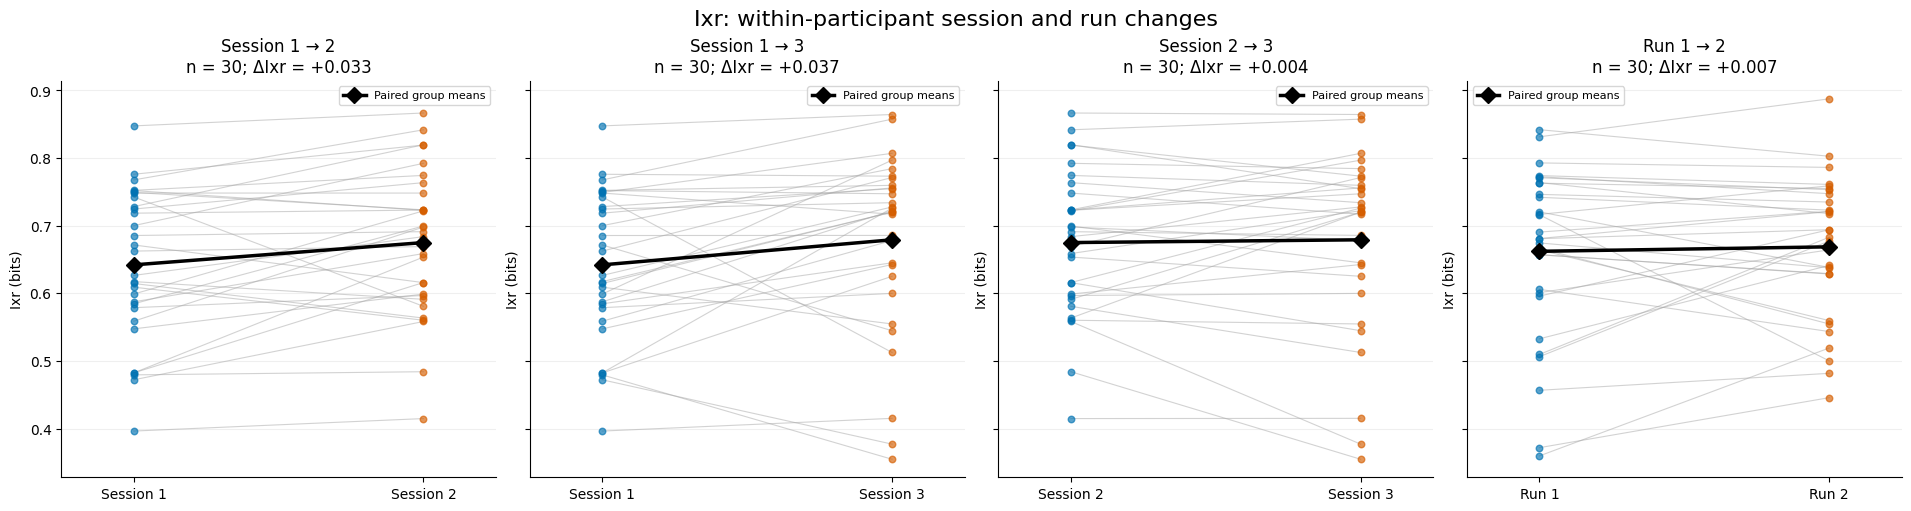

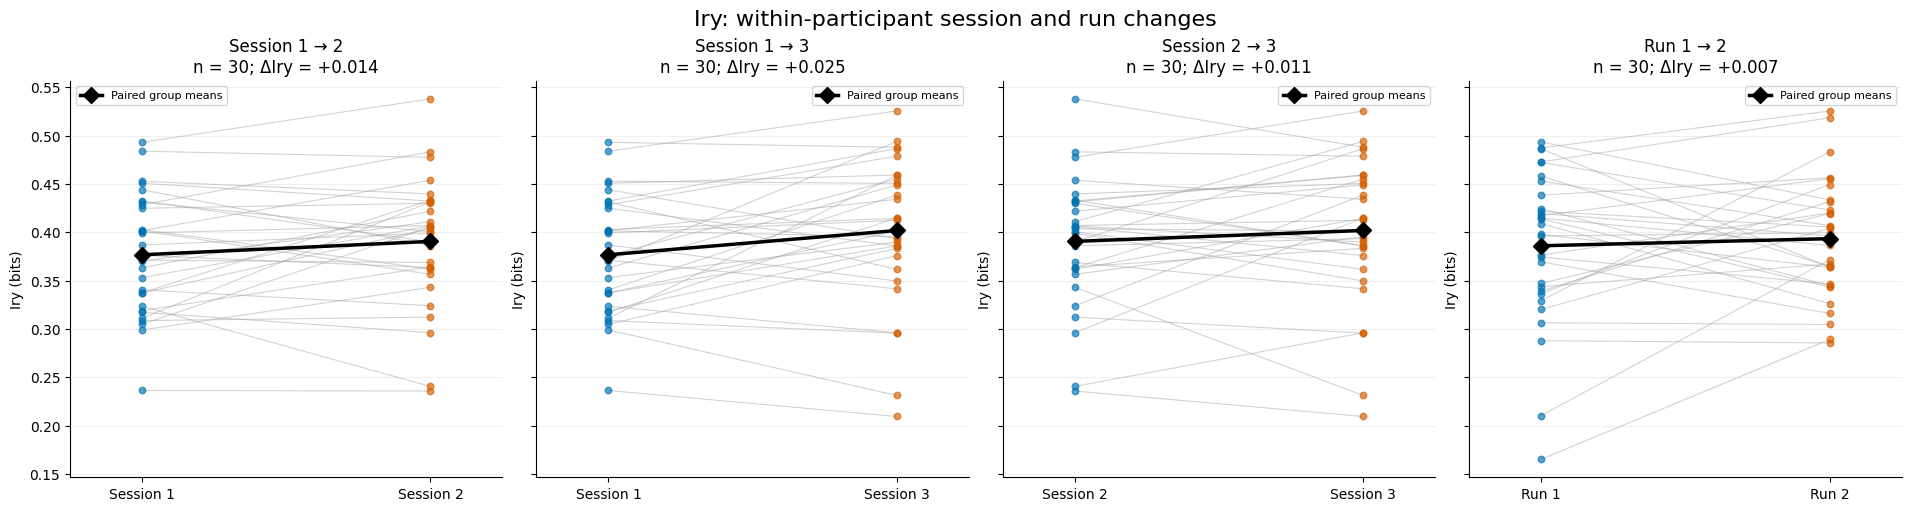

In [33]:
# Self-contained plotting section: run after loading/computing ibdf.
order_df = ibdf[['subject_ID', 'session', 'run', 'Ixr', 'Iry']].copy()
for column in ['session', 'run', 'Ixr', 'Iry']:
    order_df[column] = pd.to_numeric(order_df[column], errors='coerce')
order_df = order_df.loc[order_df['session'].isin([1, 2, 3]) & order_df['run'].isin([1, 2])]
if order_df.duplicated(['subject_ID', 'session', 'run']).any():
    raise ValueError('Expected one ibdf row per participant, session, and run.')
order_df[['Ixr', 'Iry']] = order_df[['Ixr', 'Iry']].replace([np.inf, -np.inf], np.nan)
order_df = order_df.dropna(subset=['subject_ID', 'Ixr', 'Iry'])

# Require complete contributing runs/sessions before averaging.
def order_means(factor, expected_rows):
    grouped = order_df.groupby(['subject_ID', factor], observed=True)
    means = grouped[['Ixr', 'Iry']].mean()
    return means.loc[grouped.size().eq(expected_rows)].reset_index()

session_means = order_means('session', 2)
run_means = order_means('run', 3)
order_comparisons = []
for factor, means, contrasts in [
    ('session', session_means, [(1, 2), (1, 3), (2, 3)]),
    ('run', run_means, [(1, 2)]),
]:
    for first, second in contrasts:
        left = means.loc[means[factor] == first].set_index('subject_ID')[['Ixr', 'Iry']]
        right = means.loc[means[factor] == second].set_index('subject_ID')[['Ixr', 'Iry']]
        pairs = left.join(right, how='inner', lsuffix='_1', rsuffix='_2').dropna()
        order_comparisons.append({
            'title': f'{factor.capitalize()} {first} → {second}',
            'labels': (f'{factor.capitalize()} {first}', f'{factor.capitalize()} {second}'),
            'pairs': pairs,
        })

order_colors = ('#0072B2', '#D55E00')

def order_title(comparison, measures):
    pairs = comparison['pairs']
    delta = ', '.join(
        f"Δ{m} = {(pairs[m + '_2'] - pairs[m + '_1']).mean():+.3f}"
        for m in measures
    ) if len(pairs) else 'No complete pairs'
    return f"{comparison['title']}\nn = {len(pairs)}; {delta}"

def order_figure(title, joint=False):
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=joint, sharey=True,
                             constrained_layout=True)
    fig.suptitle(title, fontsize=16)
    return fig, axes

order_measure_figures = {}
for measure in ['Ixr', 'Iry']:
    fig, axes = order_figure(f'{measure}: within-participant session and run changes')
    for ax, comparison in zip(axes, order_comparisons):
        values = comparison['pairs'][[measure + '_1', measure + '_2']].to_numpy()
        if len(values):
            ax.plot([0, 1], values.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
            for j, color in enumerate(order_colors):
                ax.scatter(np.full(len(values), j), values[:, j], color=color,
                           s=22, alpha=0.65, zorder=2)
            ax.plot([0, 1], values.mean(axis=0), '-D', color='black', lw=2.5,
                    markersize=8, label='Paired group means', zorder=3)
            ax.legend(fontsize=8)
        ax.set(xticks=[0, 1], xticklabels=comparison['labels'], xlim=(-0.25, 1.25),
               ylabel=f'{measure} (bits)', title=order_title(comparison, [measure]))
        ax.grid(axis='y', alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)
    order_measure_figures[measure] = fig
    plt.show()


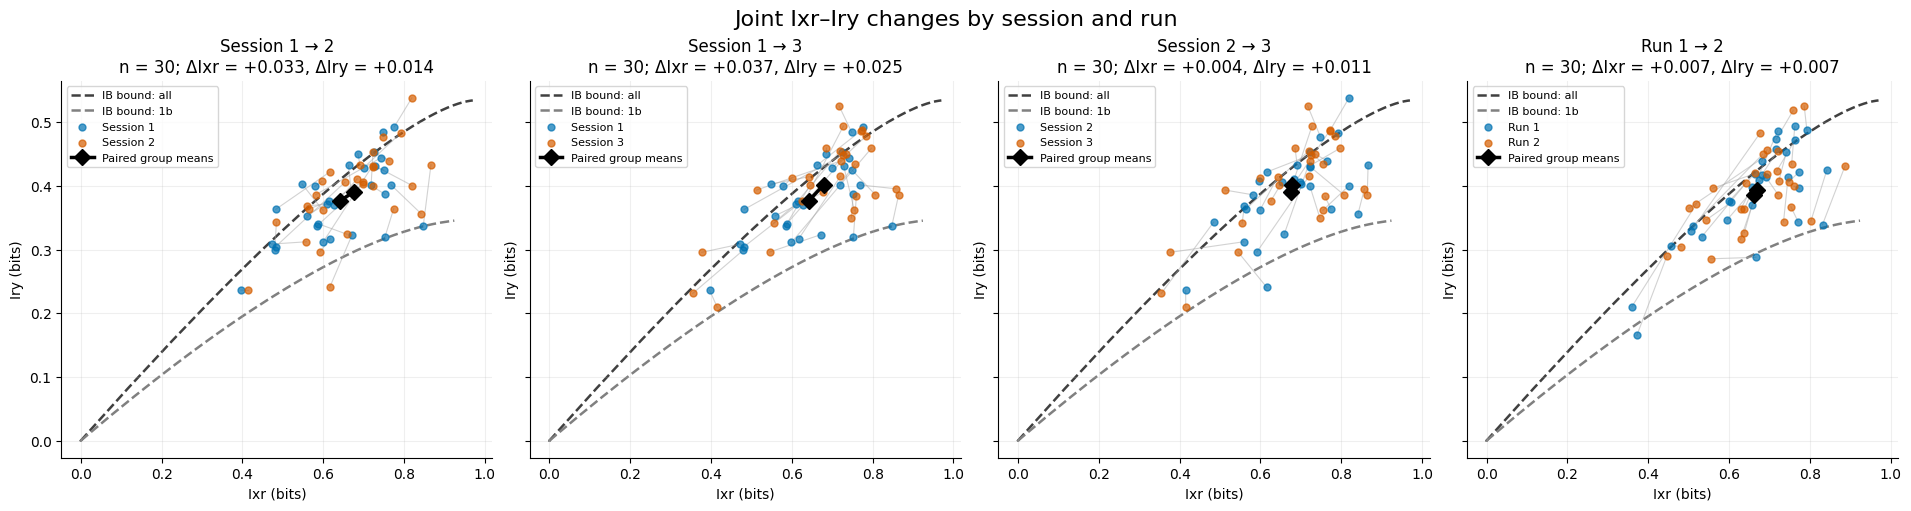

In [34]:
order_joint_figure, axes = order_figure('Joint Ixr–Iry changes by session and run', joint=True)
for ax, comparison in zip(axes, order_comparisons):
    ax.plot(IB_bound_low['I_XR'], IB_bound_low['I_RY'], '--', color='0.25', lw=1.8,
        label='IB bound: all', zorder=0)
    ax.plot(IB_bound_low1b['I_XR'], IB_bound_low1b['I_RY'], '--', color='0.5', lw=1.8,
        label='IB bound: 1b', zorder=0)
    # H-specific IB curves from the existing bounds dictionary.
#     ax.plot(bounds['0.1']['I_XR'], bounds['0.1']['I_RY'],
#             '--', color='0.25', lw=1.8, label='IB bound: H = 0.1 (reference)', zorder=0)
#     ax.plot(bounds['0.9']['I_XR'], bounds['0.9']['I_RY'],
#             ':', color='0.25', lw=1.8, label='IB bound: H = 0.9 (reference)', zorder=0)
    pairs = comparison['pairs']
    if len(pairs):
        xs = pairs[['Ixr_1', 'Ixr_2']].to_numpy()
        ys = pairs[['Iry_1', 'Iry_2']].to_numpy()
        ax.plot(xs.T, ys.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
        for j, (label, color) in enumerate(zip(comparison['labels'], order_colors)):
            ax.scatter(xs[:, j], ys[:, j], color=color, s=25, alpha=0.7,
                       label=label, zorder=2)
        ax.plot(xs.mean(axis=0), ys.mean(axis=0), '-D', color='black', lw=2.5,
                markersize=8, label='Paired group means', zorder=3)
    ax.legend(fontsize=8)
    ax.set(xlabel='Ixr (bits)', ylabel='Iry (bits)',
           title=order_title(comparison, ['Ixr', 'Iry']))
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()


## Session and run comparisons at H = 0.1

Use only `H = 0.1` and compare sessions **1 → 2**, **1 → 3**, **2 → 3**, and runs **1 → 2**. Within each participant and condition, average the information estimates within each drug first, then average across the available drugs with equal drug weights. These are averages of the existing estimates, not estimates recomputed from pooled trials.

In this study each session corresponds to one drug and contains only one H = 0.1 run. Session values therefore retain that single drug's estimate; there is no within-session drug average to compute. For run comparisons each participant contributes one or two drugs to each run average. These descriptive averages do not adjust for differences in the contributing drugs or session order.

Thin lines connect the same participant across conditions. Black diamonds mark paired group means; titles show complete-pair counts and mean changes in bits. Participants with finite values for both measures in both conditions are included. This section is independent of the earlier plotting sections and can run after loading `ibdf`.

The joint plots overlay the H = 0.1 IB bound from `bounds['0.1']` as a dashed curve. Run the cell defining `bounds` before the joint plotting cell.

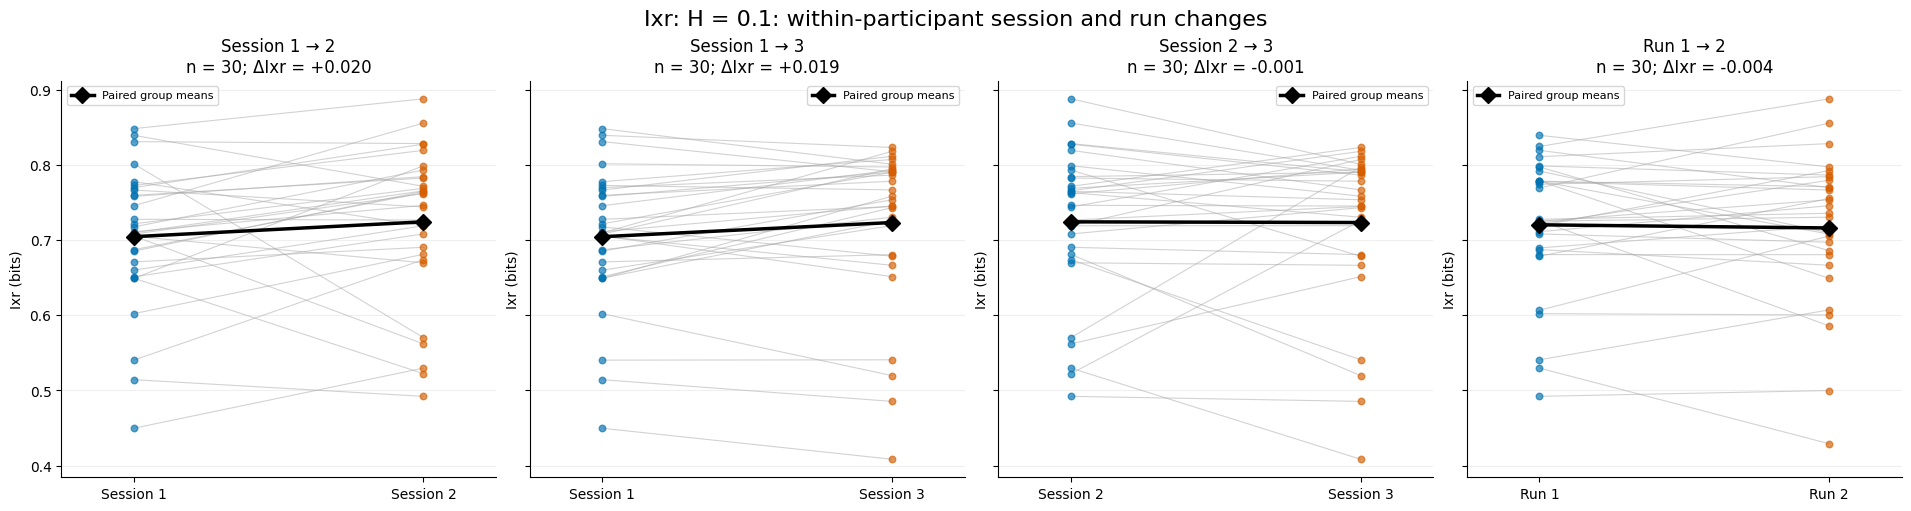

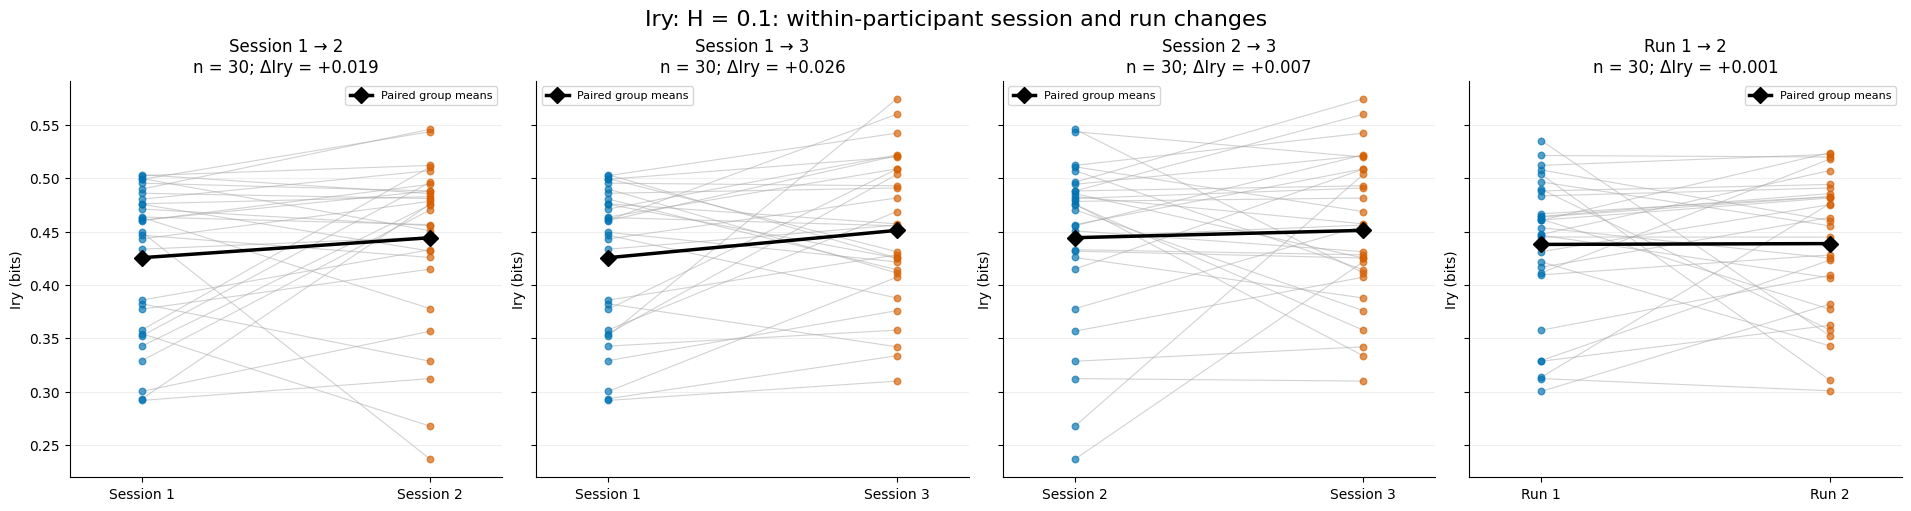

In [39]:
# Self-contained plotting section: run after loading/computing ibdf.
lowh_order_df = ibdf[['subject_ID', 'session', 'run', 'drug', 'H', 'Ixr', 'Iry']].copy()
for column in ['H', 'session', 'run', 'Ixr', 'Iry']:
    lowh_order_df[column] = pd.to_numeric(lowh_order_df[column], errors='coerce')
lowh_order_df = lowh_order_df.loc[lowh_order_df['H'].eq(0.1) & lowh_order_df['session'].isin([1, 2, 3]) & lowh_order_df['run'].isin([1, 2])]
if lowh_order_df.duplicated(['subject_ID', 'session', 'run', 'drug']).any():
    raise ValueError('Expected one H=0.1 row per participant, session, run, and drug.')
lowh_order_df[['Ixr', 'Iry']] = lowh_order_df[['Ixr', 'Iry']].replace([np.inf, -np.inf], np.nan)
lowh_order_df = lowh_order_df.dropna(subset=['subject_ID', 'Ixr', 'Iry'])

# Average first within drug, then across available drugs with equal drug weights.
# In this study each session has one drug; run groups have one or two drugs.
def lowh_order_means(factor):
    by_drug = lowh_order_df.groupby(['subject_ID', factor, 'drug'], observed=True)[['Ixr', 'Iry']].mean()
    return by_drug.groupby(level=['subject_ID', factor])[['Ixr', 'Iry']].mean().reset_index()

lowh_session_means = lowh_order_means('session')
lowh_run_means = lowh_order_means('run')
lowh_order_comparisons = []
for factor, means, contrasts in [
    ('session', lowh_session_means, [(1, 2), (1, 3), (2, 3)]),
    ('run', lowh_run_means, [(1, 2)]),
]:
    for first, second in contrasts:
        left = means.loc[means[factor] == first].set_index('subject_ID')[['Ixr', 'Iry']]
        right = means.loc[means[factor] == second].set_index('subject_ID')[['Ixr', 'Iry']]
        pairs = left.join(right, how='inner', lsuffix='_1', rsuffix='_2').dropna()
        lowh_order_comparisons.append({
            'title': f'{factor.capitalize()} {first} → {second}',
            'labels': (f'{factor.capitalize()} {first}', f'{factor.capitalize()} {second}'),
            'pairs': pairs,
        })

lowh_order_colors = ('#0072B2', '#D55E00')

def lowh_order_title(comparison, measures):
    pairs = comparison['pairs']
    delta = ', '.join(
        f"Δ{m} = {(pairs[m + '_2'] - pairs[m + '_1']).mean():+.3f}"
        for m in measures
    ) if len(pairs) else 'No complete pairs'
    return f"{comparison['title']}\nn = {len(pairs)}; {delta}"

def lowh_order_figure(title, joint=False):
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=joint, sharey=True,
                             constrained_layout=True)
    fig.suptitle(title, fontsize=16)
    return fig, axes

lowh_order_measure_figures = {}
for measure in ['Ixr', 'Iry']:
    fig, axes = lowh_order_figure(f'{measure}: H = 0.1: within-participant session and run changes')
    for ax, comparison in zip(axes, lowh_order_comparisons):
        values = comparison['pairs'][[measure + '_1', measure + '_2']].to_numpy()
        if len(values):
            ax.plot([0, 1], values.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
            for j, color in enumerate(lowh_order_colors):
                ax.scatter(np.full(len(values), j), values[:, j], color=color,
                           s=22, alpha=0.65, zorder=2)
            ax.plot([0, 1], values.mean(axis=0), '-D', color='black', lw=2.5,
                    markersize=8, label='Paired group means', zorder=3)
            ax.legend(fontsize=8)
        ax.set(xticks=[0, 1], xticklabels=comparison['labels'], xlim=(-0.25, 1.25),
               ylabel=f'{measure} (bits)', title=lowh_order_title(comparison, [measure]))
        ax.grid(axis='y', alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)
    lowh_order_measure_figures[measure] = fig
    plt.show()


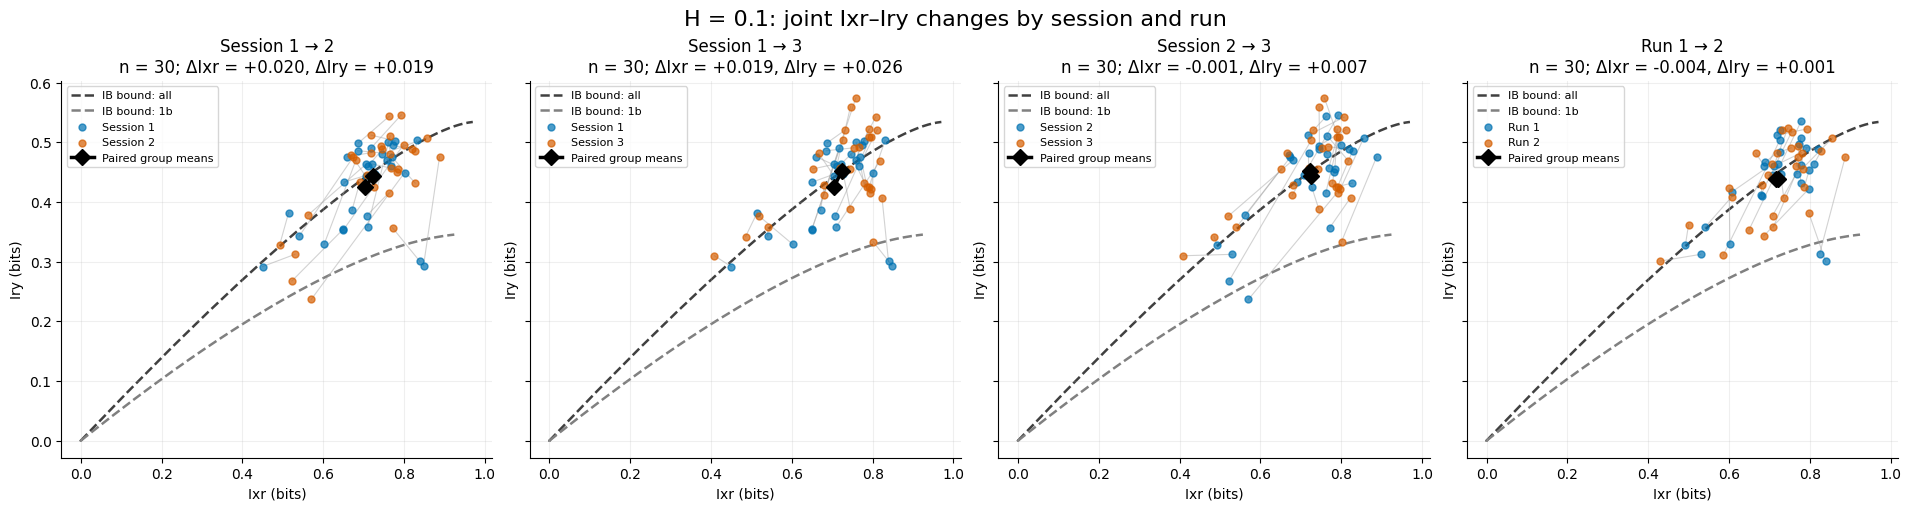

In [40]:
lowh_order_joint_figure, axes = lowh_order_figure('H = 0.1: joint Ixr–Iry changes by session and run', joint=True)
for ax, comparison in zip(axes, lowh_order_comparisons):
    ax.plot(IB_bound_low['I_XR'], IB_bound_low['I_RY'], '--', color='0.25', lw=1.8,
            label='IB bound: all', zorder=0)
    ax.plot(IB_bound_low1b['I_XR'], IB_bound_low1b['I_RY'], '--', color='0.5', lw=1.8,
            label='IB bound: 1b', zorder=0)
    # H-specific IB curves from the existing bounds dictionary.
    # ax.plot(bounds['0.1']['I_XR'], bounds['0.1']['I_RY'],
    #         '--', color='0.25', lw=1.8, label='IB bound: H = 0.1', zorder=0)
    pairs = comparison['pairs']
    if len(pairs):
        xs = pairs[['Ixr_1', 'Ixr_2']].to_numpy()
        ys = pairs[['Iry_1', 'Iry_2']].to_numpy()
        ax.plot(xs.T, ys.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
        for j, (label, color) in enumerate(zip(comparison['labels'], lowh_order_colors)):
            ax.scatter(xs[:, j], ys[:, j], color=color, s=25, alpha=0.7,
                       label=label, zorder=2)
        ax.plot(xs.mean(axis=0), ys.mean(axis=0), '-D', color='black', lw=2.5,
                markersize=8, label='Paired group means', zorder=3)
    ax.legend(fontsize=8)
    ax.set(xlabel='Ixr (bits)', ylabel='Iry (bits)',
           title=lowh_order_title(comparison, ['Ixr', 'Iry']))
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()


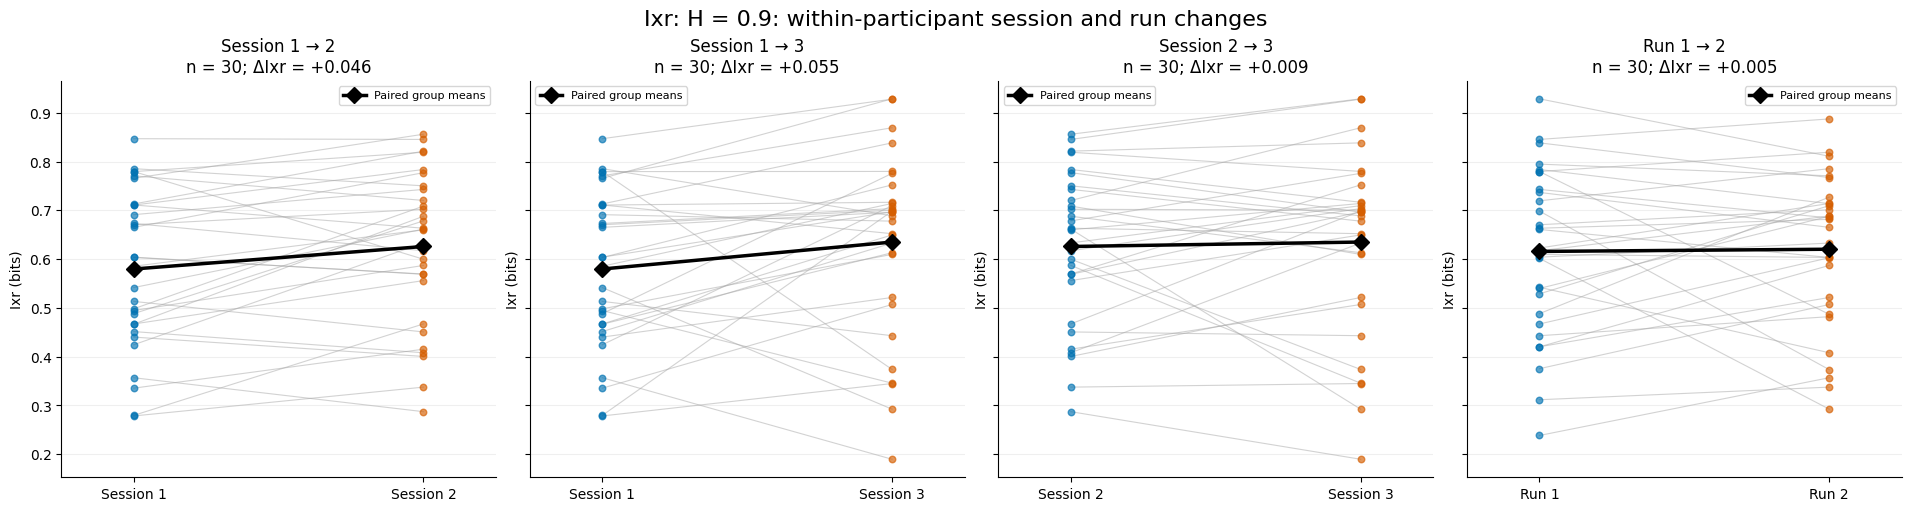

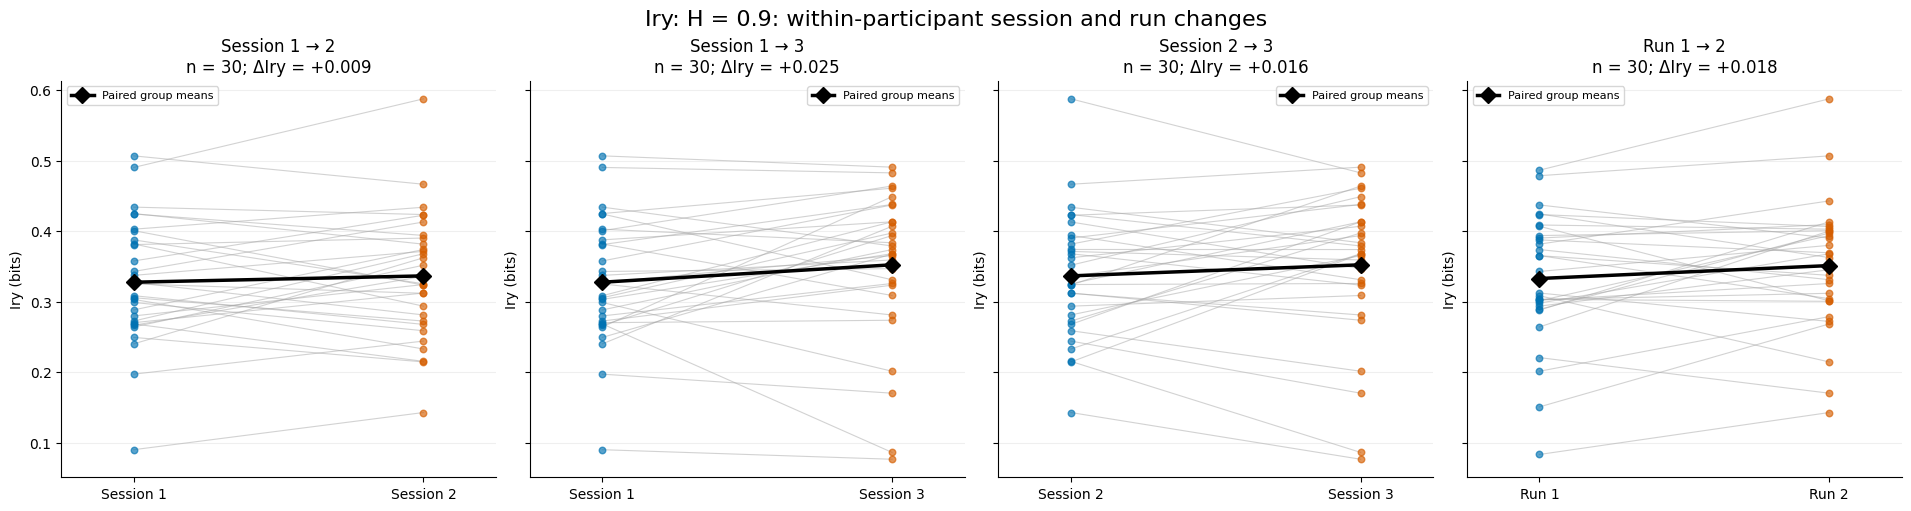

In [41]:
# Self-contained plotting section: run after loading/computing ibdf.
highh_order_df = ibdf[['subject_ID', 'session', 'run', 'drug', 'H', 'Ixr', 'Iry']].copy()
for column in ['H', 'session', 'run', 'Ixr', 'Iry']:
    highh_order_df[column] = pd.to_numeric(highh_order_df[column], errors='coerce')
highh_order_df = highh_order_df.loc[highh_order_df['H'].eq(0.9) & highh_order_df['session'].isin([1, 2, 3]) & highh_order_df['run'].isin([1, 2])]
if highh_order_df.duplicated(['subject_ID', 'session', 'run', 'drug']).any():
    raise ValueError('Expected one H=0.9 row per participant, session, run, and drug.')
highh_order_df[['Ixr', 'Iry']] = highh_order_df[['Ixr', 'Iry']].replace([np.inf, -np.inf], np.nan)
highh_order_df = highh_order_df.dropna(subset=['subject_ID', 'Ixr', 'Iry'])

# Average first within drug, then across available drugs with equal drug weights.
# In this study each session has one drug; run groups have one or two drugs.
def highh_order_means(factor):
    by_drug = highh_order_df.groupby(['subject_ID', factor, 'drug'], observed=True)[['Ixr', 'Iry']].mean()
    return by_drug.groupby(level=['subject_ID', factor])[['Ixr', 'Iry']].mean().reset_index()

highh_session_means = highh_order_means('session')
highh_run_means = highh_order_means('run')
highh_order_comparisons = []
for factor, means, contrasts in [
    ('session', highh_session_means, [(1, 2), (1, 3), (2, 3)]),
    ('run', highh_run_means, [(1, 2)]),
]:
    for first, second in contrasts:
        left = means.loc[means[factor] == first].set_index('subject_ID')[['Ixr', 'Iry']]
        right = means.loc[means[factor] == second].set_index('subject_ID')[['Ixr', 'Iry']]
        pairs = left.join(right, how='inner', lsuffix='_1', rsuffix='_2').dropna()
        highh_order_comparisons.append({
            'title': f'{factor.capitalize()} {first} → {second}',
            'labels': (f'{factor.capitalize()} {first}', f'{factor.capitalize()} {second}'),
            'pairs': pairs,
        })

highh_order_colors = ('#0072B2', '#D55E00')

def highh_order_title(comparison, measures):
    pairs = comparison['pairs']
    delta = ', '.join(
        f"Δ{m} = {(pairs[m + '_2'] - pairs[m + '_1']).mean():+.3f}"
        for m in measures
    ) if len(pairs) else 'No complete pairs'
    return f"{comparison['title']}\nn = {len(pairs)}; {delta}"

def highh_order_figure(title, joint=False):
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharex=joint, sharey=True,
                             constrained_layout=True)
    fig.suptitle(title, fontsize=16)
    return fig, axes

highh_order_measure_figures = {}
for measure in ['Ixr', 'Iry']:
    fig, axes = highh_order_figure(f'{measure}: H = 0.9: within-participant session and run changes')
    for ax, comparison in zip(axes, highh_order_comparisons):
        values = comparison['pairs'][[measure + '_1', measure + '_2']].to_numpy()
        if len(values):
            ax.plot([0, 1], values.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
            for j, color in enumerate(highh_order_colors):
                ax.scatter(np.full(len(values), j), values[:, j], color=color,
                           s=22, alpha=0.65, zorder=2)
            ax.plot([0, 1], values.mean(axis=0), '-D', color='black', lw=2.5,
                    markersize=8, label='Paired group means', zorder=3)
            ax.legend(fontsize=8)
        ax.set(xticks=[0, 1], xticklabels=comparison['labels'], xlim=(-0.25, 1.25),
               ylabel=f'{measure} (bits)', title=highh_order_title(comparison, [measure]))
        ax.grid(axis='y', alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)
    lowh_order_measure_figures[measure] = fig
    plt.show()


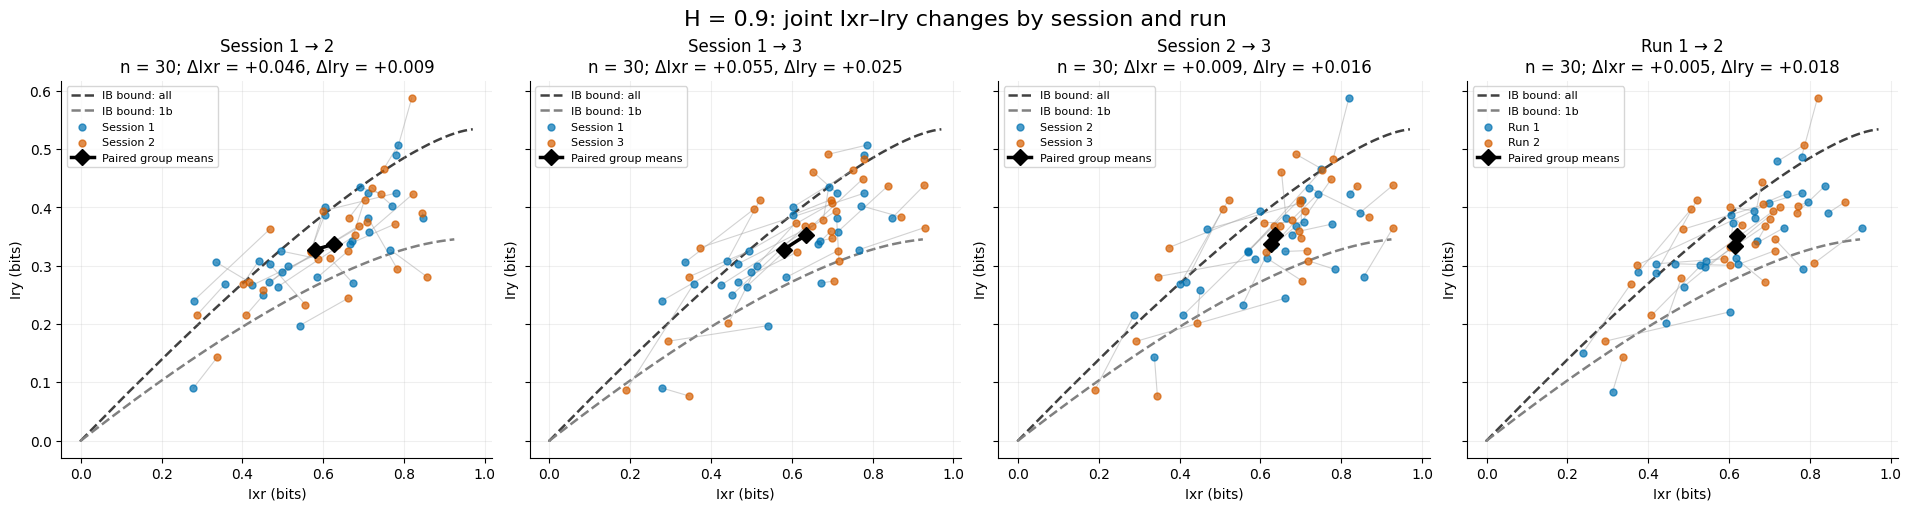

In [42]:
highh_order_joint_figure, axes = highh_order_figure('H = 0.9: joint Ixr–Iry changes by session and run', joint=True)
for ax, comparison in zip(axes, highh_order_comparisons):
    ax.plot(IB_bound_low['I_XR'], IB_bound_low['I_RY'], '--', color='0.25', lw=1.8,
            label='IB bound: all', zorder=0)
    ax.plot(IB_bound_low1b['I_XR'], IB_bound_low1b['I_RY'], '--', color='0.5', lw=1.8,
            label='IB bound: 1b', zorder=0)
    # H-specific IB curves from the existing bounds dictionary.
    # ax.plot(bounds['0.1']['I_XR'], bounds['0.1']['I_RY'],
    #         '--', color='0.25', lw=1.8, label='IB bound: H = 0.1', zorder=0)
    pairs = comparison['pairs']
    if len(pairs):
        xs = pairs[['Ixr_1', 'Ixr_2']].to_numpy()
        ys = pairs[['Iry_1', 'Iry_2']].to_numpy()
        ax.plot(xs.T, ys.T, color='0.65', alpha=0.5, lw=0.8, zorder=1)
        for j, (label, color) in enumerate(zip(comparison['labels'], highh_order_colors)):
            ax.scatter(xs[:, j], ys[:, j], color=color, s=25, alpha=0.7,
                       label=label, zorder=2)
        ax.plot(xs.mean(axis=0), ys.mean(axis=0), '-D', color='black', lw=2.5,
                markersize=8, label='Paired group means', zorder=3)
    ax.legend(fontsize=8)
    ax.set(xlabel='Ixr (bits)', ylabel='Iry (bits)',
           title=highh_order_title(comparison, ['Ixr', 'Iry']))
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)
plt.show()
